In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer
from sklearn.linear_model import LinearRegression
font1 = {'weight': 'bold', 'size': 18}

In [2]:
df_ne = pd.read_csv('LMP_DISPATCH_121_NUCLEAR_1.csv')
df_load = pd.read_csv('Real_Time_load_hourly.csv')

total_load = df_load['1'] + df_load['2'] + df_load['3']
tot_load = total_load.to_numpy()

# set the LMP >= 100 to 100 (for visualization)
# df_ne[df_ne['LMP']>=100] = 100

## Simple Price-Load Relationship

In [3]:
# fig, ax = plt.subplots(figsize=(16,12))
# ax.plot(tot_load)
# ax.set_ylim(0, 8000)
# ax2 = ax.twinx()
# ax2.plot(df_ne['LMP'], c='r')

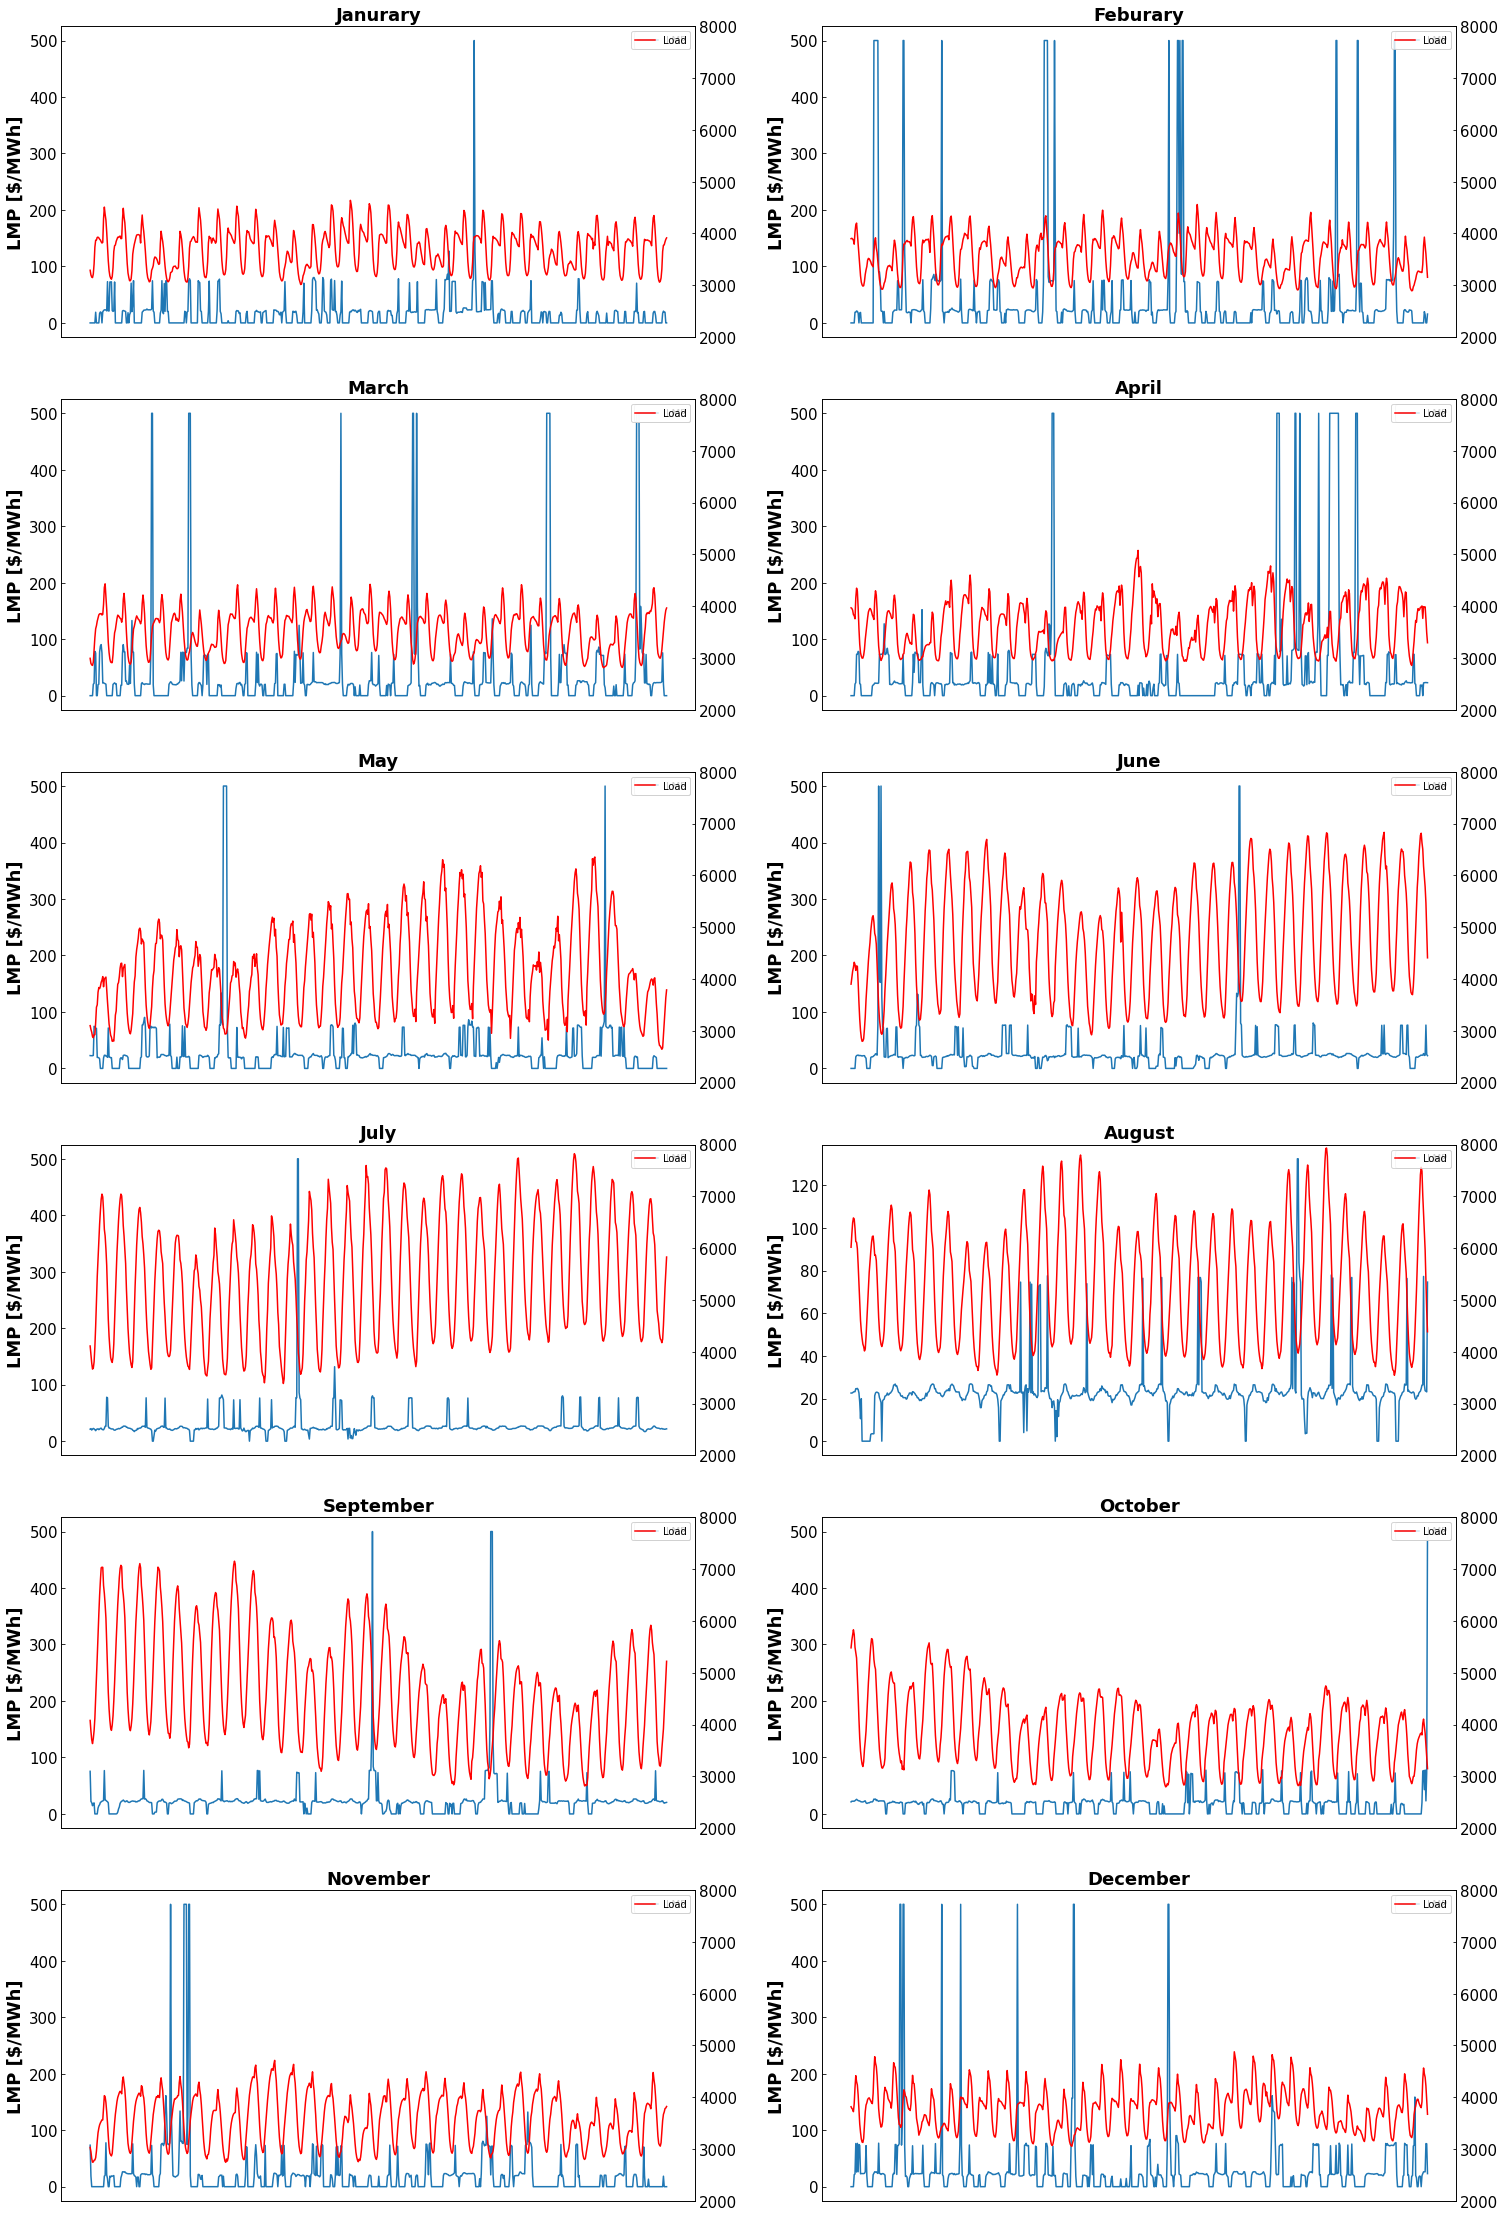

In [4]:
# Line plot
fig, axs = plt.subplots(6,2, figsize=(25, 40))
Month = ['Janurary', 'Feburary', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
c = 0

for i in range(6):
    for j in range(2):
        axs[i, j].tick_params(direction='in', top=True, right=True, labelsize = 15)
        axs[i, j].set_xticks([])
        axs[i, j].set_ylabel('LMP [$/MWh]', font=font1)
        axs[i, j].set_title(Month[c*2+j], font=font1)
        axs[i, j].plot(df_ne['LMP'][int(len(df_ne['LMP'].index)*(2*c+j)/12):int(len(df_ne['LMP'].index)*(2*c+(1+j))/12)], label='LMP')
        axs2 = axs[i, j].twinx()
        axs2.tick_params(direction='in', top=True, right=True, labelsize = 15)
        axs2.plot(total_load[int(len(total_load.index)*(2*c+j)/12):int(len(total_load.index)*(2*c+(1+j))/12)], c='r', label='Load')
        axs2.set_ylim(2000, 8000)
        #         axs2.set_ylabel('Capacity Factor', font=font1)
#         axs2.tick_params(direction='in', top=True, right=True, labelsize = 15)
        axs[i,j].legend(loc='upper right')
        axs2.legend(loc='upper right')
    c += 1


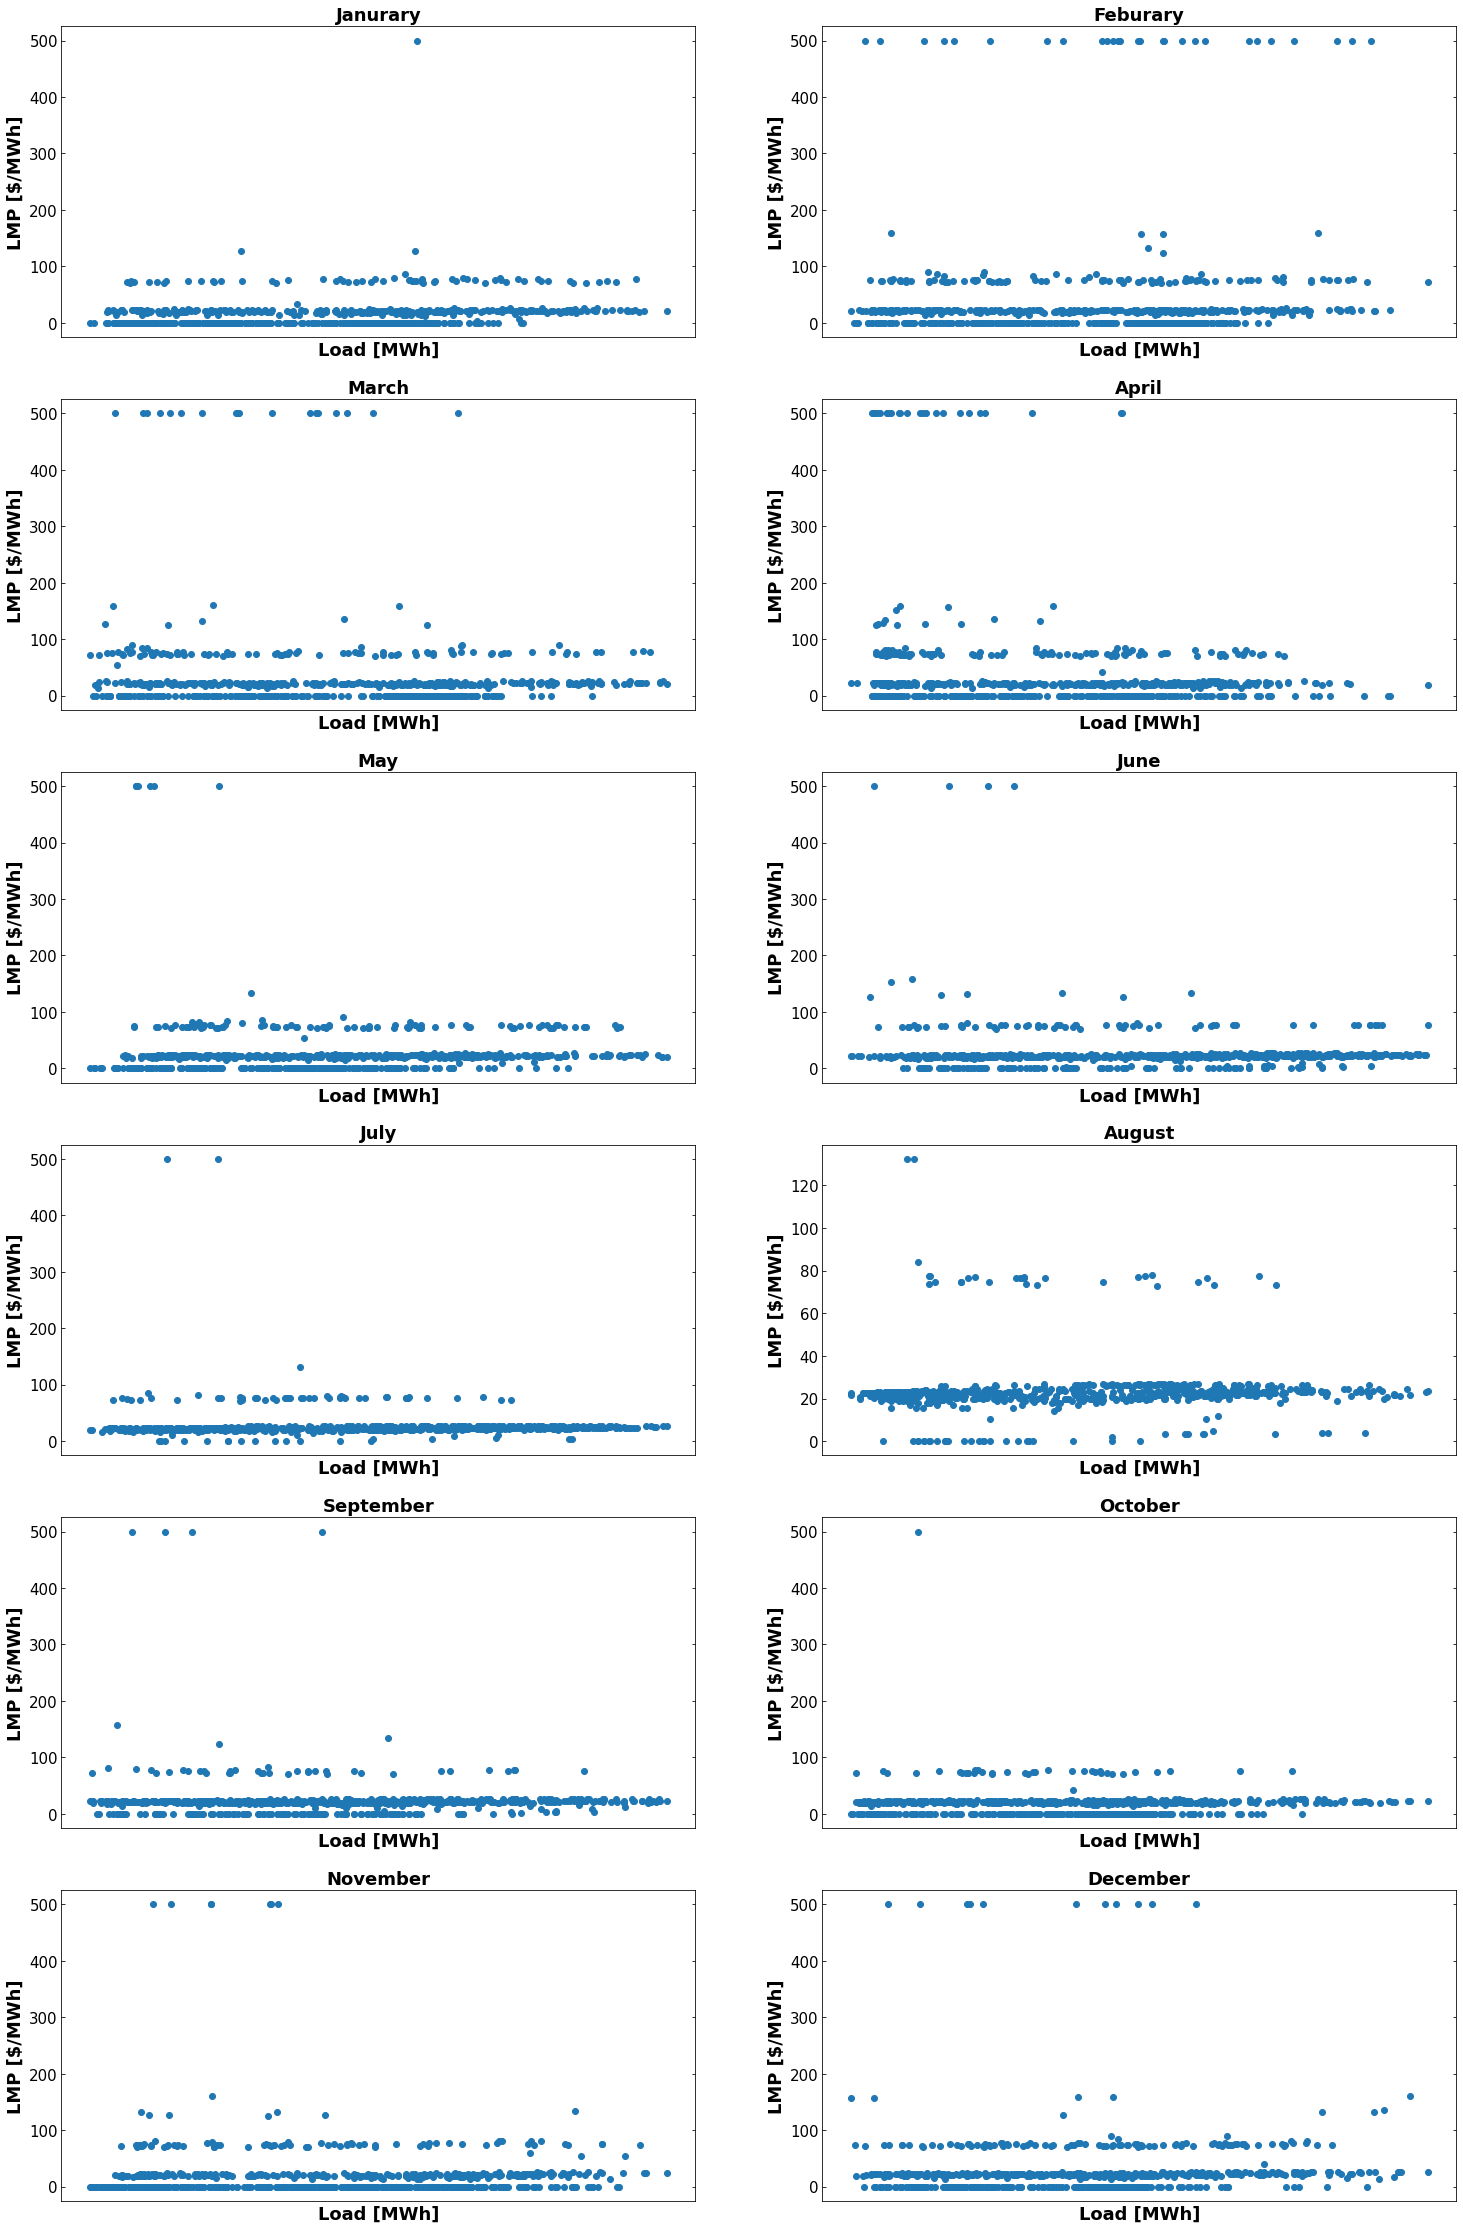

In [7]:
# Line plot
fig, axs = plt.subplots(6,2, figsize=(25, 40))
Month = ['Janurary', 'Feburary', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
c = 0

for i in range(6):
    for j in range(2):
        axs[i, j].tick_params(direction='in', top=True, right=True, labelsize = 15)
        axs[i, j].set_xticks([])
        axs[i, j].set_ylabel('LMP [$/MWh]', font=font1)
        axs[i, j].set_title(Month[c*2+j], font=font1)
        axs[i, j].scatter(total_load[int(len(total_load.index)*(2*c+j)/12):int(len(total_load.index)*(2*c+(1+j))/12)], df_ne['LMP'][int(len(df_ne['LMP'].index)*(2*c+j)/12):int(len(df_ne['LMP'].index)*(2*c+(1+j))/12)])
        axs[i, j].set_xlabel('Load [MWh]', font=font1)
    c += 1


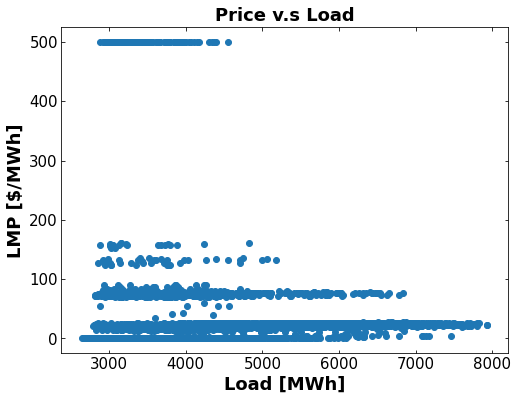

In [8]:

fig, ax = plt.subplots(figsize=(8, 6))
ax.tick_params(direction='in', top=True, right=True, labelsize = 15)
ax.scatter(tot_load, df_ne["LMP"].to_numpy())
ax.set_ylabel('LMP [$/MWh]', font=font1)
ax.set_xlabel('Load [MWh]', font=font1)
ax.set_title('Price v.s Load', font=font1)
plt.show()

## Consider Renewables

### Plot total-load - renewable vs price 

In [9]:
df_wind = pd.read_csv('Real_Time_wind_hourly.csv')
df_pv = pd.read_csv('Real_Time_pv_hourly.csv')
df_rtpv = pd.read_csv('Real_Time_rtpv_hourly.csv')
df_hydro = pd.read_csv('Real_Time_hydro_hourly.csv')
df_csp = pd.read_csv('Real_Time_csp_hourly.csv')

# extract every generator unit data
def sum_single_renewable(df):
    re_sum_all = []
    for index, row in df.iterrows():
        re_sum = 0
        re_sum = row[df.columns[5:]].sum()
        re_sum_all.append(re_sum)
    
    return re_sum_all

wind_sum_all = sum_single_renewable(df_wind)
pv_sum_all = sum_single_renewable(df_pv)
rtpv_sum_all = sum_single_renewable(df_rtpv)
hydro_sum_all = sum_single_renewable(df_hydro)
csp_sum_all = sum_single_renewable(df_csp)

renew_sum_all = np.array(wind_sum_all) + np.array(pv_sum_all) + np.array(rtpv_sum_all) + np.array(hydro_sum_all) + np.array(csp_sum_all)
renew_sum_all

array([2637.5  , 2620.44 , 2584.862, ...,  560.562,  522.762,  564.602])

In [10]:
dispatable_unit_load = tot_load - renew_sum_all
df = pd.DataFrame({
    'Dispatch Load': dispatable_unit_load,
    'LMP': df_ne["LMP"].to_numpy()
})

df[(df['Dispatch Load'] >= 0) & (df['LMP'] == 0.0)]

df

,Dispatch Load,LMP
0,652.030156,0.000000
1,577.419856,0.000000
2,573.841060,0.000000
3,661.401413,0.000000
4,641.440182,0.000000
...,...,...
8779,3914.497997,26.324557
8780,3888.780274,26.324557
8781,3656.666558,76.324557
8782,3429.247378,75.908700


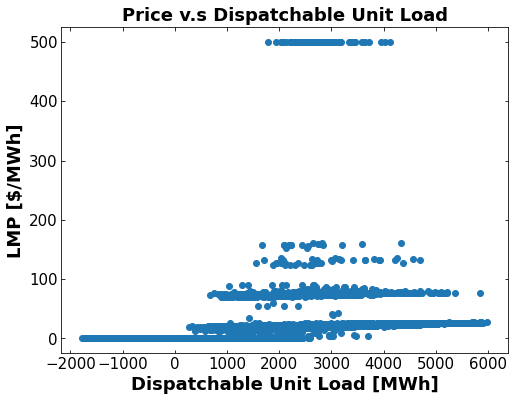

In [11]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.tick_params(direction='in', top=True, right=True, labelsize = 15)
ax.scatter(dispatable_unit_load, df_ne["LMP"].to_numpy())
ax.set_ylabel('LMP [$/MWh]', font=font1)
ax.set_xlabel('Dispatchable Unit Load [MWh]', font=font1)
ax.set_title('Price v.s Dispatchable Unit Load', font=font1)
plt.show()

In [12]:
from idaes.apps.grid_integration.utils import convert_marginal_costs_to_actual_costs
from egret.model_library.transmission import tx_utils

In [13]:
bids = [(30, 14.19), (45.33, 14.19), (60.67, 16.97), (76, 18.07)]
cost_paris = convert_marginal_costs_to_actual_costs(bids)
temp_curve = {
    "data_type": "cost_curve",
    "cost_curve_type": "piecewise",
    "values": cost_paris,
}
tx_utils.validate_and_clean_cost_curve(curve=temp_curve, curve_type="cost_curve", p_min=30, p_max=76, gen_name='103_STEAM_3', t=0)

[(30, 425.7), (45.33, 643.2327), (60.67, 903.5525), (76, 1180.5656)]

## Use Decision Tree

All features
1. Load (total load in the entire grid)
2. Renewable used
3. Renewable curtailment
4. Volume/Load
5. Available headroom
6. Load at zone_1
7. reserve shortfall
8. load shedding

### 121_NUCLEAR_1

#### Read the inputs

In [36]:
# Read renewable used and curtailment
df_hourly = pd.read_csv("hourly_summary.csv")
renew_used = df_hourly["RenewablesUsed"].to_numpy()
renew_curtailment = df_hourly["RenewablesCurtailment"].to_numpy()

# Calculate the NE volume ratio
dispatch_ratio = df_ne["121_NUCLEAR_1 Dispatch"].to_numpy()/tot_load

# read available headroom
df_gen_sum = pd.read_csv("hourly_gen_summary.csv")
headroom = df_gen_sum["Available headroom"].to_numpy()

# read LMP (y)
y = df_ne["LMP"].to_numpy()
np.shape(y)


# other features
res_shortfall = df_gen_sum["Reserve shortfall"].to_numpy()
load_shedding = df_gen_sum["Load shedding"].to_numpy()
# over_gen = df_gen_sum["Over generation"].to_numpy() # overgen are all 0

#### Check the input size

In [50]:
# check the input data shape
print(np.shape(renew_used))
print(np.shape(renew_curtailment))
print(np.shape(tot_load))
print(np.shape(dispatch_ratio))
print(np.shape(headroom))
print(np.shape(df_load['1'].to_numpy()))
print(np.shape(res_shortfall))
print(np.shape(load_shedding))

(8784,)
(8784,)
(8784,)
(8784,)
(8784,)
(8784,)
(8784,)
(8784,)


#### Calculate pearson correlation


In [38]:
from scipy.stats import pearsonr

correlation_coefficient, p_value = pearsonr(tot_load, y)
print("total load:", f"Pearson correlation: {correlation_coefficient}, p-value: {p_value}")

correlation_coefficient, p_value = pearsonr(renew_used, y)
print("renew_used:", f"Pearson correlation: {correlation_coefficient}, p-value: {p_value}")

correlation_coefficient, p_value = pearsonr(renew_curtailment, y)
print("renew_curtailment:", f"Pearson correlation: {correlation_coefficient}, p-value: {p_value}")

correlation_coefficient, p_value = pearsonr(dispatch_ratio, y)
print("dispatch_ratio:", f"Pearson correlation: {correlation_coefficient}, p-value: {p_value}")

correlation_coefficient, p_value = pearsonr(headroom, y)
print("headroom:", f"Pearson correlation: {correlation_coefficient}, p-value: {p_value}")

print("==============================================================================")

correlation_coefficient, p_value = pearsonr(df_load['1'].to_numpy(), y)
print("load at zone1:", f"Pearson correlation: {correlation_coefficient}, p-value: {p_value}")

correlation_coefficient, p_value = pearsonr(res_shortfall, y)
print("res_shortfall:", f"Pearson correlation: {correlation_coefficient}, p-value: {p_value}")

correlation_coefficient, p_value = pearsonr(load_shedding, y)
print("load_shedding:", f"Pearson correlation: {correlation_coefficient}, p-value: {p_value}")

# correlation_coefficient, p_value = pearsonr(over_gen, y)
# print("over_gen:", f"Pearson correlation: {correlation_coefficient}, p-value: {p_value}")

total load: Pearson correlation: -0.0474875119026363, p-value: 8.485632334121045e-06
renew_used: Pearson correlation: -0.28307954515348377, p-value: 1.5565738932085785e-161
renew_curtailment: Pearson correlation: -0.21535656743592274, p-value: 1.0869884390093688e-92
dispatch_ratio: Pearson correlation: -0.014408831883975409, p-value: 0.17691438567820506
headroom: Pearson correlation: -0.4420541137701117, p-value: 0.0
load at zone1: Pearson correlation: -0.03174007845063499, p-value: 0.0029289168668119236
res_shortfall: Pearson correlation: 0.7889716905676895, p-value: 0.0
load_shedding: Pearson correlation: 0.6932360776566369, p-value: 0.0


#### Train test split.

In [51]:
# train test split (3 features)
X_3 = np.vstack((renew_used, tot_load, dispatch_ratio))
X_3 = X_3.T

In [52]:
# train test split (4 features)
X_4 = np.vstack((renew_used, renew_curtailment, tot_load, dispatch_ratio))
X_4 = X_4.T

In [59]:
# train test split (5 features)
X_5 = np.vstack((renew_used, renew_curtailment, tot_load, dispatch_ratio, headroom))
X_5 = X_5.T

In [41]:
# train test split (8 features)
X_all = np.vstack((renew_used, renew_curtailment, tot_load, dispatch_ratio, headroom, df_load['1'].to_numpy(), res_shortfall, load_shedding))
X_all = X_all.T

In [66]:
X = X_5

X_train, X_test, y_train, y_test = train_test_split(
    X, y,                # data and target
    test_size=0.2,       # 20% for testing, 80% for training
    random_state=42      # for reproducibility
)

#### Train the model, GridSearch to do hyperparameter optimization

In [67]:
# fit the regressor
param_grid = {'max_depth': [1,2,3,4,5,6,7,8,9,10, None]}

# Use negative MSE so we can maximize the score
grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=0),
    param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    return_train_score=True
)
grid_search.fit(X_train, y_train)

print("Best hyperparameters:", grid_search.best_params_)

# Train on the full training dataset
regressor = DecisionTreeRegressor(
    random_state=0,
    max_depth=grid_search.best_params_['max_depth']
)

# fit the model
regressor.fit(X_train, y_train)

# predict
y_test_pred = regressor.predict(X_test)
y_train_pred = regressor.predict(X_train)

Best hyperparameters: {'max_depth': 7}


In [18]:
## Old method
# regressor = DecisionTreeRegressor(max_depth=6)
# regressor.fit(X_train, y_train)
# y_test_pred = regressor.predict(X_test)
# y_train_pred = regressor.predict(X_train)

## Cross validation try
# scoring = make_scorer(mean_absolute_error, greater_is_better=False)
# scores = cross_val_score(regressor, X_train, y_train, cv=5, scoring=scoring)
# scores

In [68]:
# calculate MAE, R2
def calculate_performance_metric(y_test, y_test_pred, y_train, y_train_pred):
    test_mae = mean_absolute_error(y_test, y_test_pred)
    test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)
    test_r2 = r2_score(y_test, y_test_pred)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
    train_r2 = r2_score(y_train, y_train_pred)

    print(f"Train MAE: {np.round(train_mae, 4)}")
    print(f"Train MSE: {np.round(train_rmse, 4)}")
    print(f"Train R2: {np.round(train_r2, 4)}")
    print("====================================")
    print(f"Test MAE: {np.round(test_mae, 4)}")
    print(f"Test MSE: {np.round(test_rmse, 4)}")
    print(f"Test R2: {np.round(test_r2, 4)}")
    
    return
calculate_performance_metric(y_test, y_test_pred, y_train, y_train_pred)

Train MAE: 2.9882
Train MSE: 6.1657
Train R2: 0.9886
Test MAE: 3.5027
Test MSE: 7.8896
Test R2: 0.9789


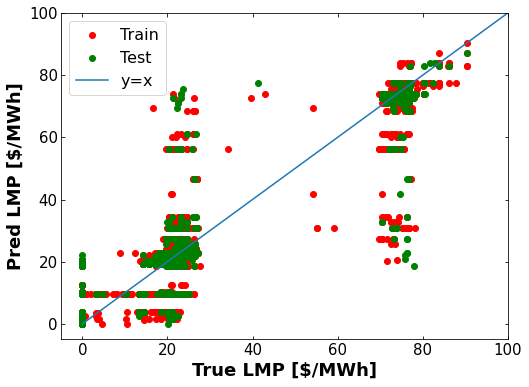

In [69]:
# parity plot
def make_parity_plot(y_test, y_test_pred, y_train, y_train_pred):
    
    plt.figure(figsize=(8, 6))
    plt.scatter(y_train, y_train_pred, c="r", label="Train")
    plt.scatter(y_test, y_test_pred, c="g", label="Test")
    plt.plot(np.linspace(0,500), np.linspace(0,500), label="y=x")
    plt.xlim(-5,100)
    plt.ylim(-5,100)
    plt.legend(prop={"size":16})
    plt.xlabel("True LMP [$/MWh]", font=font1)
    plt.ylabel("Pred LMP [$/MWh]", font=font1)
    plt.tick_params(direction='in', top=True, right=True, labelsize = 15)
    
    return
make_parity_plot(y_test, y_test_pred, y_train, y_train_pred)

0.8321001707455891


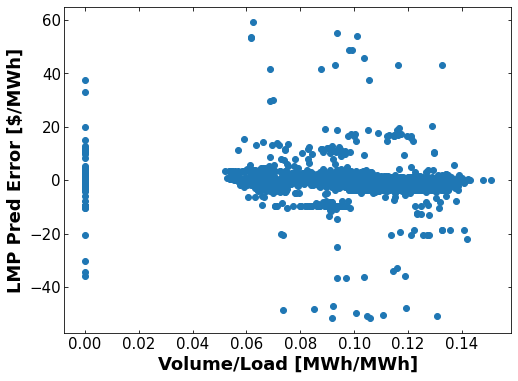

In [160]:
## V/D vs prediction error
plt.figure(figsize=(8, 6))
pred_err = (y_test - y_test_pred)
plt.scatter(X_test[:,3], pred_err)
plt.xlabel("Volume/Load [MWh/MWh]", font=font1)
plt.ylabel("LMP Pred Error [$/MWh]", font=font1)
plt.tick_params(direction='in', top=True, right=True, labelsize = 15)

c_low = 0
for i in pred_err:
    if abs(i) <= 3.985:
        c_low += 1
print(c_low/len(pred_err))

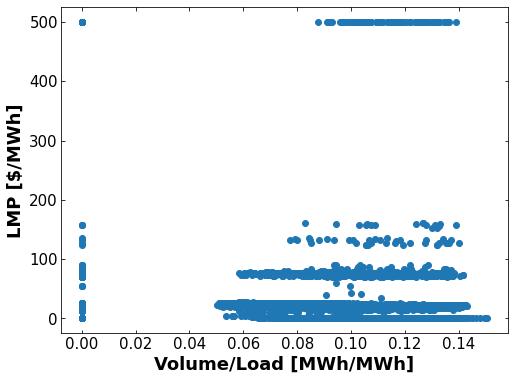

In [161]:
# V/D vs LMP
plt.figure(figsize=(8, 6))
plt.scatter(dispatch_ratio, y)
plt.xlabel("Volume/Load [MWh/MWh]", font=font1)
plt.ylabel("LMP [$/MWh]", font=font1)
plt.tick_params(direction='in', top=True, right=True, labelsize = 15)

(array([0.00051217, 0.00046096, 0.00081948, 0.00507052, 0.07600662,
        0.00496809, 0.00122922, 0.00015365, 0.00040974, 0.00035852]),
 array([-51.8218181 , -40.70934555, -29.59687299, -18.48440044,
         -7.37192788,   3.74054467,  14.85301722,  25.96548978,
         37.07796233,  48.19043489,  59.30290744]),
 <BarContainer object of 10 artists>)

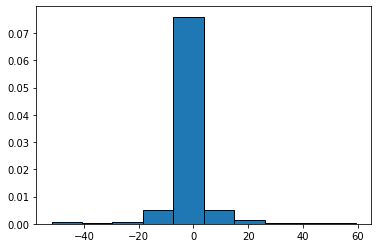

In [162]:
plt.hist(pred_err, bins=10, density=True, edgecolor='black')

## Use linear regression

In [59]:
model = LinearRegression()
model.fit(X_train, y_train)

y_test_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

In [60]:
# calculate MAE, R2
calculate_performance_metric(y_test, y_test_pred, y_train, y_train_pred)

Train MAE: 21.9242
Train MSE: 48.9386
Train R2: 0.2839
Test MAE: 21.0112
Train MSE: 45.9441
Test R2: 0.2852


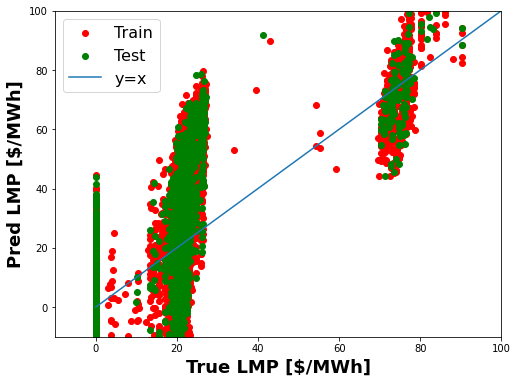

In [61]:
make_parity_plot(y_test, y_test_pred, y_train, y_train_pred)

## Use Neural Network

In [22]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import MeanSquaredError

In [23]:
# Define model creation function
def create_model():
    model = Sequential([
        Dense(32, activation='relu', input_shape=(X.shape[1],)),
        Dense(16, activation='relu'),
#         Dense(32, activation='relu'),
        Dense(1)  # Regression output
    ])
    model.compile(optimizer=Adam(learning_rate=0.01), loss='mse')
    return model

model = create_model()
model.fit(X_train, y_train, epochs=60, batch_size=32, verbose=1)

Epoch 1/60
220/220 [==============================] - 1s 822us/step - loss: 5823.4619
Epoch 2/60
220/220 [==============================] - 0s 868us/step - loss: 1087.6165
Epoch 3/60
220/220 [==============================] - 0s 854us/step - loss: 819.9898
Epoch 4/60
220/220 [==============================] - 0s 810us/step - loss: 721.1033
Epoch 5/60
220/220 [==============================] - 0s 819us/step - loss: 562.9850
Epoch 6/60
220/220 [==============================] - 0s 815us/step - loss: 553.1898
Epoch 7/60
220/220 [==============================] - 0s 828us/step - loss: 520.3278
Epoch 8/60
220/220 [==============================] - 0s 981us/step - loss: 542.1544
Epoch 9/60
220/220 [==============================] - 0s 826us/step - loss: 474.3339
Epoch 10/60
220/220 [==============================] - 0s 809us/step - loss: 508.8495
Epoch 11/60
220/220 [==============================] - 0s 799us/step - loss: 460.7806
Epoch 12/60
220/220 [==============================] - 0s 825

In [24]:
y_test_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

220/220 [==============================] - 0s 604us/step


In [25]:
calculate_performance_metric(y_test, y_test_pred, y_train, y_train_pred)

Train MAE: 7.1155
Train MSE: 15.1165
Train R2: 0.9317
Test MAE: 7.2022
Test MSE: 15.902
Test R2: 0.9144


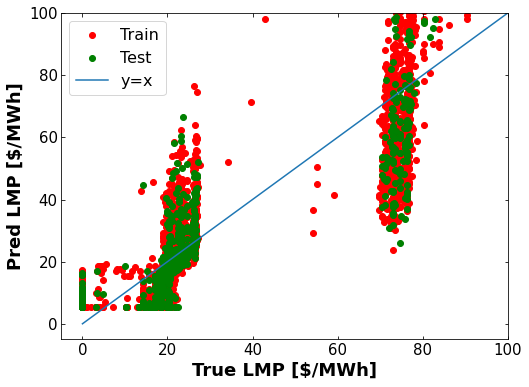

In [26]:
make_parity_plot(y_test, y_test_pred, y_train, y_train_pred)

## Random Forest

In [71]:
from sklearn.ensemble import RandomForestRegressor

In [72]:
X = X_5

X_train, X_test, y_train, y_test = train_test_split(
    X, y,                # data and target
    test_size=0.2,       # 20% for testing, 80% for training
    random_state=42      # for reproducibility
)

In [75]:
# fit the regressor
param_grid = {'n_estimators': [3, 5, 7, 9, 10, 20, 50 ,100], 'max_depth': [1,2,3,4,5,6,7,8,9,10]}

# Use negative MSE so we can maximize the score
grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    scoring='neg_mean_squared_error',
    cv=5,
    return_train_score=True
)
grid_search.fit(X_train, y_train)

print("Best hyperparameters:", grid_search.best_params_)

# Train on the full training dataset
regressor = RandomForestRegressor(
    random_state=42,
    n_estimators=grid_search.best_params_['n_estimators'], 
    max_depth=grid_search.best_params_['max_depth'],
)

# fit the model
regressor.fit(X_train, y_train)

# predict
y_test_pred = regressor.predict(X_test)
y_train_pred = regressor.predict(X_train)

Best hyperparameters: {'max_depth': 10, 'n_estimators': 100}


In [76]:
calculate_performance_metric(y_test, y_test_pred, y_train, y_train_pred)

Train MAE: 1.6489
Train MSE: 3.5348
Train R2: 0.9963
Test MAE: 2.5164
Test MSE: 6.3886
Test R2: 0.9862


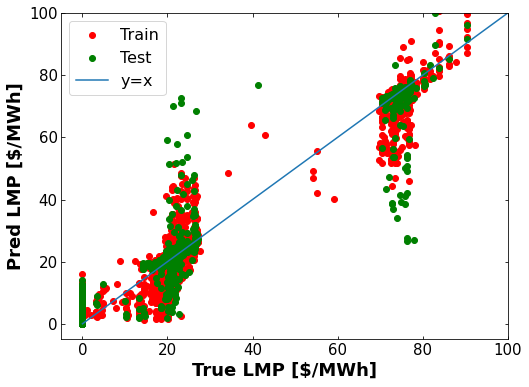

In [77]:
make_parity_plot(y_test, y_test_pred, y_train, y_train_pred)